In [1]:
!pip install textblob
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
import seaborn as sns

In [4]:
df = pd.read_csv('student_feedback.csv')
df.head()

,Unnamed: 0,Student ID,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance
0,0,340,5,2,7,6,9,2,1,8
1,1,253,6,5,8,6,2,1,2,9
2,2,680,7,7,6,5,4,2,3,1
3,3,806,9,6,7,1,5,9,4,6
4,4,632,8,10,8,4,6,6,9,9


In [7]:
df_null_summary = df.isnull().sum().reset_index()
df_null_summary.columns = ['Column Name', 'Missing Values']
display(df_null_summary)

,Column Name,Missing Values
0,Unnamed: 0,0
1,Student ID,0
2,Well versed with the subject,0
3,Explains concepts in an understandable way,0
4,Use of presentations,0
5,Degree of difficulty of assignments,0
6,Solves doubts willingly,0
7,Structuring of the course,0
8,Provides support for students going above and ...,0
9,Course recommendation based on relevance,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.dtypes

Unnamed: 0                                              int64
Student ID                                              int64
Well versed with the subject                            int64
Explains concepts in an understandable way              int64
Use of presentations                                    int64
Degree of difficulty of assignments                     int64
Solves doubts willingly                                 int64
Structuring of the course                               int64
Provides support for students going above and beyond    int64
Course recommendation based on relevance                int64
dtype: object

In [16]:
#rating columns
rating_columns = ['Well versed with the subject',
                  'Explains concepts in an understandable way',
                  'Use of presentations',
                  'Degree of difficulty of assignments',
                  'Solves doubts willingly',
                  'Structuring of the course',
                  'Provides support for students going above and beyond',
                  'Course recommendation based on relevance']

# Average rating
avg_ratings = df[rating_columns].mean().round(1)

print(avg_ratings)


Well versed with the subject                            7.5
Explains concepts in an understandable way              6.1
Use of presentations                                    5.9
Degree of difficulty of assignments                     5.4
Solves doubts willingly                                 5.5
Structuring of the course                               5.6
Provides support for students going above and beyond    5.7
Course recommendation based on relevance                5.6
dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_16640\2818886771.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_ratings.values, y=avg_ratings.index, palette="viridis")


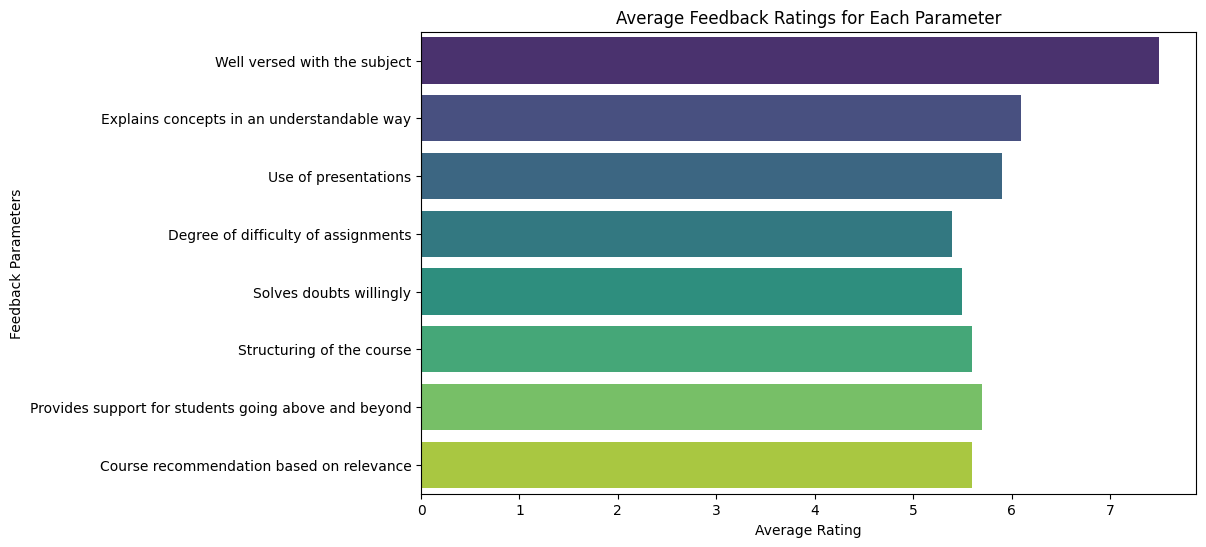

In [17]:
# Set plot size
plt.figure(figsize=(10,6))

# Plot bar chart
sns.barplot(x=avg_ratings.values, y=avg_ratings.index, palette="viridis")

# Title & labels
plt.title('Average Feedback Ratings for Each Parameter')
plt.xlabel('Average Rating')
plt.ylabel('Feedback Parameters')

# Show plot
plt.show()

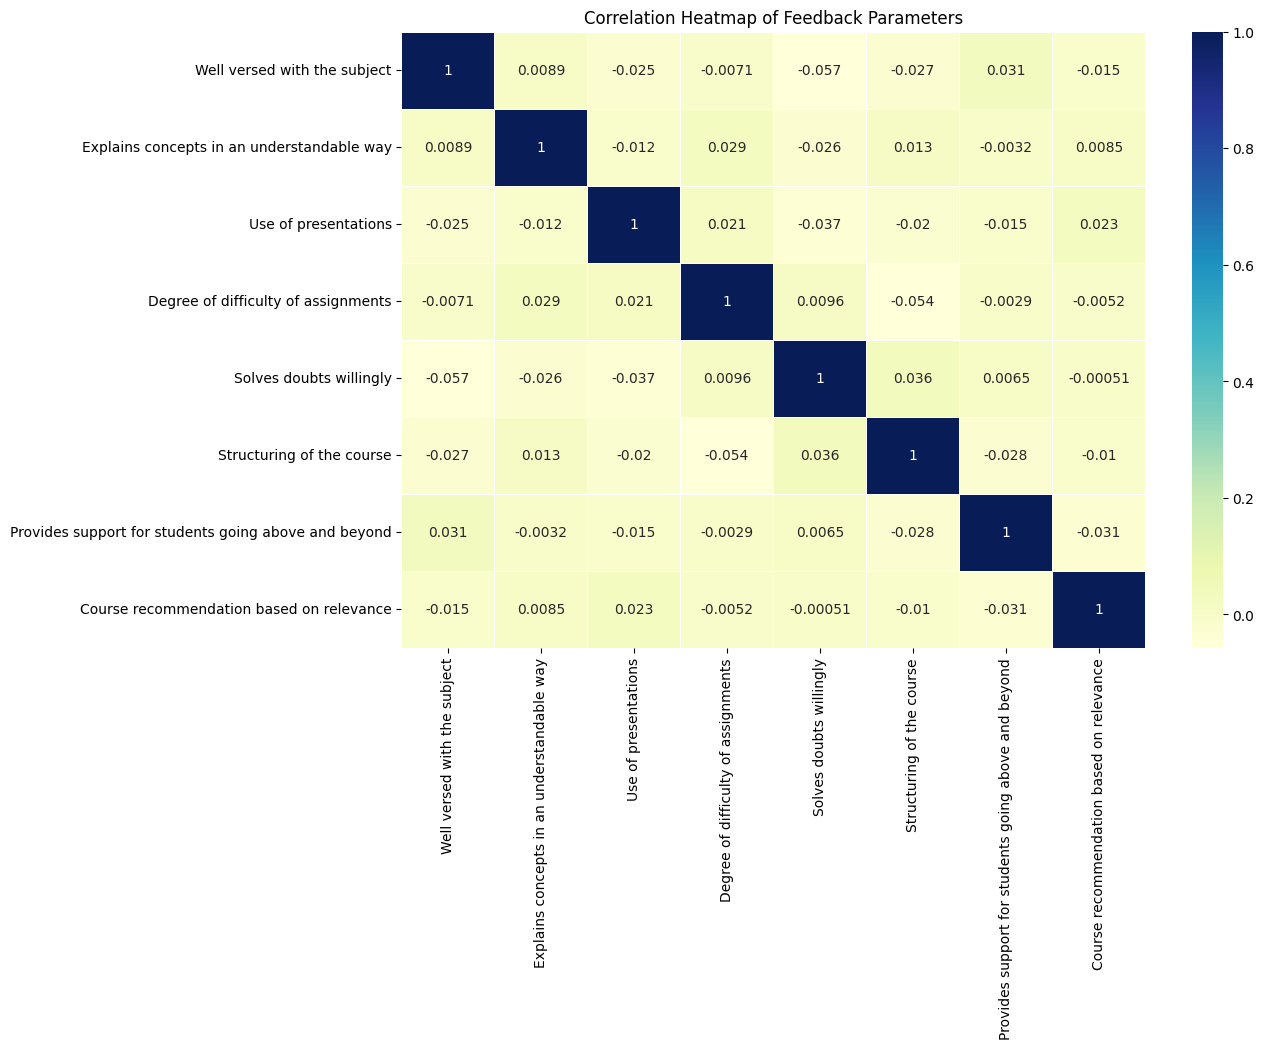

In [18]:
corr = df[rating_columns].corr()


plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="YlGnBu", linewidths=0.5)
plt.title('Correlation Heatmap of Feedback Parameters')
plt.show()

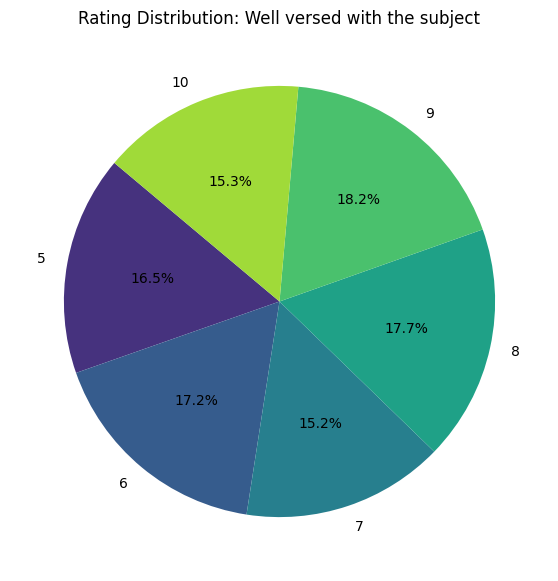

In [19]:
rating_counts = df['Well versed with the subject'].value_counts().sort_index()

plt.figure(figsize=(7,7))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(rating_counts)))
plt.title('Rating Distribution: Well versed with the subject')
plt.show()

# 📌 Insights:

Students rated "Well versed with the subject" highest on average.

"Structuring of the course" and "Degree of difficulty" had moderate scores.

Ratings across parameters were positively correlated.



# 📌 Suggestions:

Focus on improving course structuring and assignment difficulty balancing.

Conduct additional workshops for concept clarity.

Increase the number of doubt-solving sessions.